## EDA: Caudal — `caudal_tejo_loc.csv`

Caminho do dataset:
`/Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /data/caudal_tejo_loc.csv`

Objetivo: caracterizar séries por localização (cobertura, estatísticas, outliers), frequência e lacunas; exportar resumos — tudo dentro de `EDA`.


### 1) Setup de bibliotecas e configuração de paths


In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

DATA_FILE = Path("/Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /data/caudal_tejo_loc.csv")
assert DATA_FILE.exists(), f"CSV not found: {DATA_FILE}"

pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print(f"Using file: {DATA_FILE}")


Using file: /Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /data/caudal_tejo_loc.csv


### 2) Leitura do CSV e preparação de colunas

#### 2.1 Explicação do código
- `parse_dates` para `data` (diário).
- Renomeação: `caudal_médio_diário(m3/s)` -> `flow_m3s`.
- `site_id`/`site_label` a partir de `localizacao` e coordenadas.


In [2]:
parse_dates = ["data"]
df = pd.read_csv(
    DATA_FILE,
    parse_dates=parse_dates,
    dtype={
        "localizacao": "string",
        "caudal_médio_diário(m3/s)": "float32",
        "coord_x_m": "float32",
        "coord_y_m": "float32",
    },
)

rename_map = {
    "data": "date",
    "localizacao": "location",
    "caudal_médio_diário(m3/s)": "flow_m3s",
    "coord_x_m": "x_m",
    "coord_y_m": "y_m",
}
df = df.rename(columns=rename_map).sort_values("date").reset_index(drop=True)

df["year"] = df["date"].dt.year; df["month"] = df["date"].dt.month
# site id com base no nome + coordenadas
sid = df["location"].astype("string").str.extract(r"\(([^)]*)\)", expand=False).fillna("")
df["site_id"] = sid + "_" + df["y_m"].round(0).astype(int).astype(str) + "_" + df["x_m"].round(0).astype(int).astype(str)
df["site_label"] = df["location"].astype(str) + " | " + df["site_id"]

print(df.head()); df.info()


      id                      date            location  flow_m3s        x_m        y_m                     created_at  \
0  17806 1973-10-02 00:00:00+00:00  ALMOUROL (17G/02H)   183.900 179148.406 276991.625  2025-08-06 15:31:05.300551+00   
1  17807 1973-10-03 00:00:00+00:00  ALMOUROL (17G/02H)   208.200 179148.406 276991.625  2025-08-06 15:31:05.300551+00   
2  17808 1973-10-04 00:00:00+00:00  ALMOUROL (17G/02H)   153.700 179148.406 276991.625  2025-08-06 15:31:05.300551+00   
3  17809 1973-10-05 00:00:00+00:00  ALMOUROL (17G/02H)    84.800 179148.406 276991.625  2025-08-06 15:31:05.300551+00   
4  17810 1973-10-06 00:00:00+00:00  ALMOUROL (17G/02H)    52.500 179148.406 276991.625  2025-08-06 15:31:05.300551+00   

   year  month                site_id                                  site_label  
0  1973     10  17G/02H_276992_179148  ALMOUROL (17G/02H) | 17G/02H_276992_179148  
1  1973     10  17G/02H_276992_179148  ALMOUROL (17G/02H) | 17G/02H_276992_179148  
2  1973     10  17G/0

### 3) Cobertura temporal, frequência e lacunas por localização

- Estatísticas de `flow_m3s`.
- Frequência diária e dias em falta por `site_id`.
- Duplicados por `date`×`site_id`.


In [3]:
print(df[["flow_m3s"]].describe(percentiles=[0.01,0.05,0.95,0.99]))

dups = df[df.duplicated(["date","site_id"], keep=False)]
print(f"Duplicate timestamps (per site): {dups.shape[0]}")

# Frequência diária e lacunas

def compute_missing_daily(df_site: pd.DataFrame) -> tuple[int, list]:
    if df_site.empty:
        return 0, []
    start = df_site["date"].min().normalize(); end = df_site["date"].max().normalize()
    full_range = pd.date_range(start=start, end=end, freq="D")
    missing = full_range.difference(df_site["date"].dt.normalize().unique())
    return int(missing.size), [str(x.date()) for x in list(missing[:5])]

rows = []
for sid, d in df.groupby("site_id"):
    mcount, mfirst = compute_missing_daily(d)
    rows.append({
        "site_id": sid,
        "site_label": d["site_label"].iloc[0],
        "freq_label": "daily",
        "missing_count": mcount,
        "missing_first_5": ", ".join(mfirst),
    })
site_frequency_summary = pd.DataFrame(rows)
display(site_frequency_summary.head())


       flow_m3s
count 17805.000
mean    290.906
std     498.479
min       0.000
1%       15.594
5%       28.880
50%     145.870
95%    1065.486
99%    2340.766
max   13102.550
Duplicate timestamps (per site): 0


,site_id,site_label,freq_label,missing_count,missing_first_5
0,17G/02H_276992_179148,ALMOUROL (17G/02H) | 17G/02H_276992_179148,daily,986,"1973-12-03, 1973-12-04, 1973-12-10, 1973-12-11..."


### 4) Outliers e gráficos

- Outliers IQR + Z-score em `flow_m3s`.
- Gráfico agregado e dropdown por localização.


flow_m3s outliers: 1703


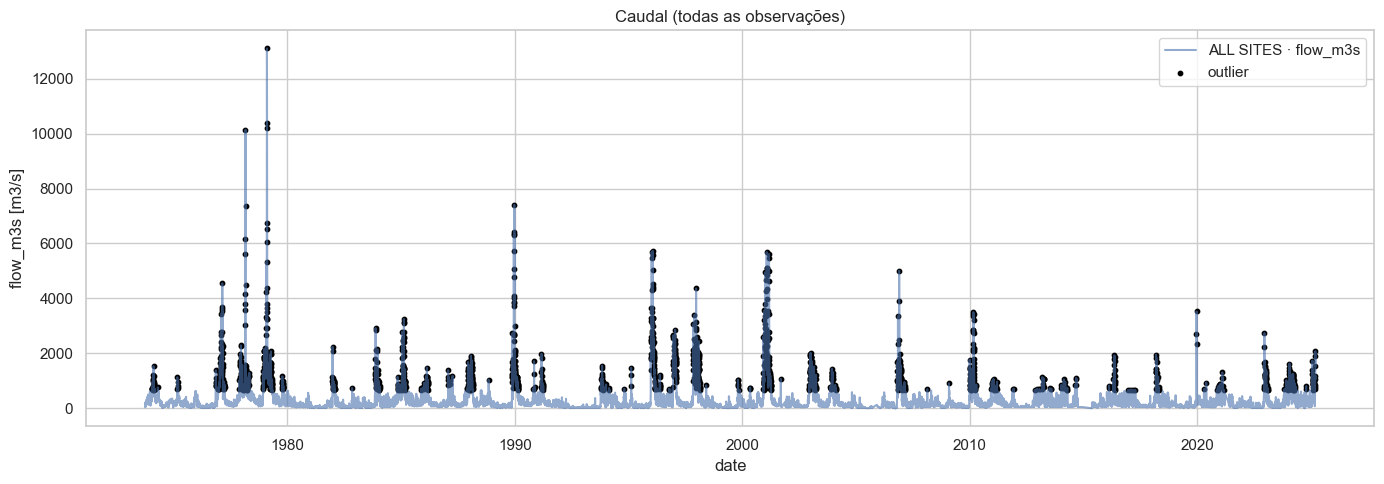

Dropdown(description='site:', options=(('ALMOUROL (17G/02H) | 17G/02H_276992_179148', '17G/02H_276992_179148')…

Output()

In [4]:
def detect_outliers_iqr(series: pd.Series, factor: float = 1.5) -> pd.Series:
    q1 = np.nanpercentile(series, 25); q3 = np.nanpercentile(series, 75)
    iqr = q3 - q1; lower = q1 - factor * iqr; upper = q3 + factor * iqr
    return (series < lower) | (series > upper)


def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    mu = np.nanmean(series); sigma = np.nanstd(series)
    if sigma == 0 or np.isnan(sigma):
        return pd.Series(False, index=series.index)
    z = (series - mu) / sigma; return z.abs() > threshold

flags = detect_outliers_iqr(df["flow_m3s"]) | detect_outliers_zscore(df["flow_m3s"]) 
df["is_outlier_flow"] = flags
print(f"flow_m3s outliers: {flags.sum()}")

plt.figure(figsize=(14,5))
plt.plot(df["date"], df["flow_m3s"], alpha=0.6, label="ALL SITES · flow_m3s")
plt.scatter(df.loc[flags, "date"], df.loc[flags, "flow_m3s"], s=10, color="black", label="outlier")
plt.legend(); plt.xlabel("date"); plt.ylabel("flow_m3s [m3/s]"); plt.title("Caudal (todas as observações)")
plt.tight_layout(); plt.show()

import ipywidgets as widgets
from IPython.display import display, clear_output
sites = sorted(df["site_id"].unique()); labels = df.groupby("site_id")["site_label"].first().to_dict()
opts = [(labels[s], s) for s in sites]; out = widgets.Output(); dd = widgets.Dropdown(options=opts, value=sites[0], description="site:")

def plot_site(sid: str):
    d = df[df["site_id"] == sid].sort_values("date"); lab = labels.get(sid, sid)
    plt.figure(figsize=(14,5))
    plt.plot(d["date"], d["flow_m3s"], label=lab)
    if "is_outlier_flow" in d.columns:
        m = d["is_outlier_flow"]; plt.scatter(d.loc[m, "date"], d.loc[m, "flow_m3s"], s=10, color="black", label="outlier")
    plt.legend(); plt.xlabel("date"); plt.ylabel("flow_m3s [m3/s]"); plt.title(f"Caudal ({lab})")
    plt.tight_layout(); plt.show()

def on_change(c):
    if c["name"] == "value":
        with out:
            clear_output(wait=True); plot_site(c["new"]) 

dd.observe(on_change, names="value"); display(dd)
with out: plot_site(dd.value)
display(out)


### 5) Resumo por localização e export

- Junta frequência e lacunas por `site_id`.
- Export para `EDA /scripts/caudal/resources/`.


In [5]:
location_summary = (
    df.groupby(["site_id", "site_label", "y_m", "x_m"]).agg(
        n_obs=("date", "count"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        mean_flow=("flow_m3s", "mean"),
        p95_flow=("flow_m3s", lambda s: np.nanpercentile(s, 95))
    ).reset_index()
)

location_summary = location_summary.merge(site_frequency_summary, on=["site_id", "site_label"], how="left")

display(location_summary.head())

from pathlib import Path
out_dir = Path("/Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /scripts/caudal/resources")
out_dir.mkdir(parents=True, exist_ok=True)

summary_stats = df[["flow_m3s"]].describe().T
summary_stats.loc["meta_unique_points", "count"] = location_summary.shape[0]

location_summary.to_csv(out_dir / "caudal_location_summary.csv", index=False)
site_frequency_summary.to_csv(out_dir / "caudal_frequency_gaps_by_site.csv", index=False)
summary_stats.to_csv(out_dir / "caudal_summary_stats.csv")

print(f"Saved summaries in: {out_dir}")


,site_id,site_label,y_m,x_m,n_obs,first_date,last_date,mean_flow,p95_flow,freq_label,missing_count,missing_first_5
0,17G/02H_276992_179148,ALMOUROL (17G/02H) | 17G/02H_276992_179148,276991.625,179148.406,17805,1973-10-02 00:00:00+00:00,2025-03-13 00:00:00+00:00,290.906,1065.486,daily,986,"1973-12-03, 1973-12-04, 1973-12-10, 1973-12-11..."


Saved summaries in: /Users/diogopinto/Documents/Usar/git_clep/clepsydra_isa/EDA /scripts/caudal/resources
